Shape: (569, 31)
Target distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64
No missing values found across all 31 columns. Dataset is clean, moving on.
Top 5 features most correlated with diagnosis:
  1. concave points_worst  (|r| = 0.794)
  2. perimeter_worst  (|r| = 0.783)
  3. concave points_mean  (|r| = 0.777)
  4. radius_worst  (|r| = 0.776)
  5. perimeter_mean  (|r| = 0.743)
Train set: 455 samples
Test set:  114 samples
Features used: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean']
Baseline Decision Tree accuracy: 0.9035


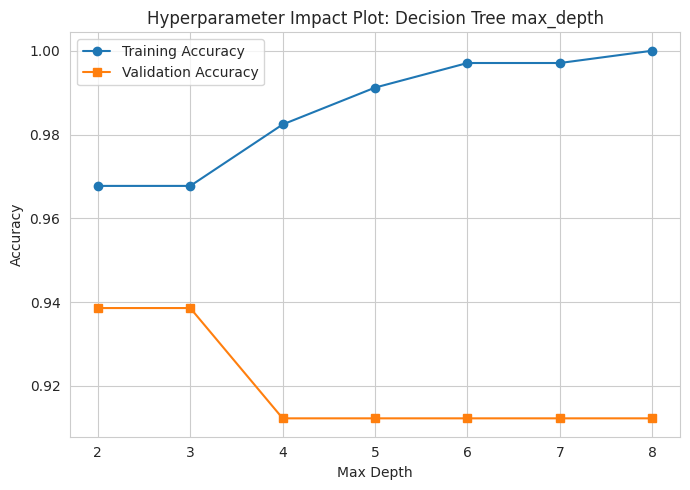

Best max_depth by validation accuracy: 2
Best GB params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best CV accuracy: 0.9495
Test accuracy: 0.9386
Best SVM params: {'C': 10, 'gamma': 1}
Best CV accuracy: 0.9516
Test accuracy: 0.9737


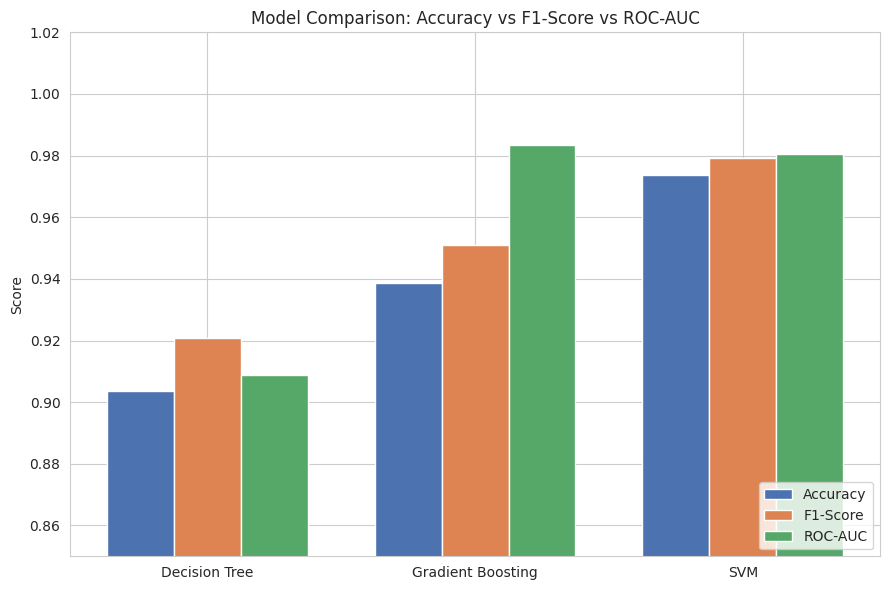

Top-performing model: SVM (test accuracy = 0.9737)


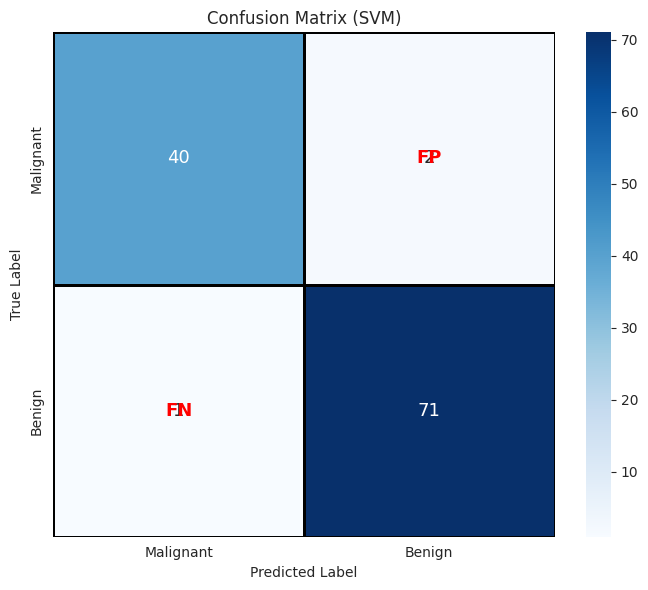


Classification report:
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        42
      Benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
# =============================================================================
# Advanced Ensemble Learning and Evaluation for Cancer Prediction
# core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42  # keeping this fixed everywhere so results are reproducible
np.random.seed(RANDOM_STATE)

# Load the dataset from the CSV file
df = pd.read_csv('/content/breast_cancer_wisconsin_dataset(1).csv')

# drop the id column (and the stray 'Unnamed: 32' column some exports of this dataset carry)
df = df.drop(columns=[c for c in ['id', 'Unnamed: 32'] if c in df.columns])

# encode diagnosis as a numeric target: 0 = malignant, 1 = benign
df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})
df = df.drop(columns=['diagnosis'])

target_names = ['Malignant', 'Benign']  # index 0 -> Malignant, index 1 -> Benign

print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts().rename(index={0: 'Malignant', 1: 'Benign'})}")
df.head()

null_counts = df.isnull().sum()
total_nulls = null_counts.sum()

if total_nulls > 0:
    print("Missing values detected:")
    print(null_counts[null_counts > 0])
else:
    print(f"No missing values found across all {df.shape[1]} columns. Dataset is clean, moving on.")

# Correlation of every feature against the target column
correlations = df.corr()['target'].drop('target').abs().sort_values(ascending=False)

top5_features = correlations.head(5).index.tolist()

print("Top 5 features most correlated with diagnosis:")
for i, feat in enumerate(top5_features, 1):
    print(f"  {i}. {feat}  (|r| = {correlations[feat]:.3f})")

X = df[top5_features].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit only on train to avoid leakage
X_test = scaler.transform(X_test_raw)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Features used: {top5_features}")

dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_baseline.fit(X_train, y_train)

dt_pred = dt_baseline.predict(X_test)
print(f"Baseline Decision Tree accuracy: {accuracy_score(y_test, dt_pred):.4f}")

from sklearn.model_selection import cross_val_score

depth_range = range(2, 9)
train_scores, val_scores = [], []

X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train
)

for depth in depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    clf.fit(X_tr_sub, y_tr_sub)
    train_scores.append(accuracy_score(y_tr_sub, clf.predict(X_tr_sub)))
    val_scores.append(accuracy_score(y_val, clf.predict(X_val)))

plt.figure(figsize=(7, 5))
plt.plot(list(depth_range), train_scores, marker='o', label='Training Accuracy')
plt.plot(list(depth_range), val_scores, marker='s', label='Validation Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Hyperparameter Impact Plot: Decision Tree max_depth")
plt.legend()
plt.tight_layout()
plt.savefig('hyperparameter_impact_plot.png')
plt.show()

best_depth = list(depth_range)[int(np.argmax(val_scores))]
print(f"Best max_depth by validation accuracy: {best_depth}")

gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print(f"Best GB params: {gb_grid.best_params_}")
print(f"Best CV accuracy: {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, gb_pred):.4f}")

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svm_grid.fit(X_train, y_train)

print(f"Best SVM params: {svm_grid.best_params_}")
print(f"Best CV accuracy: {svm_grid.best_score_:.4f}")

svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, svm_pred):.4f}")

def get_metrics(name, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else preds
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    }

results = pd.DataFrame([
    get_metrics("Decision Tree", dt_baseline, X_test, y_test),
    get_metrics("Gradient Boosting", gb_best, X_test, y_test),
    get_metrics("SVM", svm_best, X_test, y_test),
])

results.set_index('Model')

metrics_to_plot = ['Accuracy', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results[metric], width, label=metric, color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Accuracy vs F1-Score vs ROC-AUC")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison_matrix.png')
plt.show()

best_row = results.loc[results['Accuracy'].idxmax()]
best_name = best_row['Model']
best_model = {'Decision Tree': dt_baseline, 'Gradient Boosting': gb_best, 'SVM': svm_best}[best_name]

print(f"Top-performing model: {best_name} (test accuracy = {best_row['Accuracy']:.4f})")

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

labels = target_names  # ['Malignant', 'Benign'] -> index 0, 1

plt.figure(figsize=(7, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 13},
                  xticklabels=labels, yticklabels=labels, cbar=True, linewidths=1, linecolor='black')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({best_name})")

# Highlight the off-diagonal cells (False Positives / False Negatives) explicitly
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
ax.text(1.5, 0.5, "FP", color='red', fontweight='bold', fontsize=13, ha='center', va='center')
ax.text(0.5, 1.5, "FN", color='red', fontweight='bold', fontsize=13, ha='center', va='center')

plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png')
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred_best, target_names=labels))